In [87]:
import sys
import os
sys.path.append(os.path.abspath(os.pardir))

import uuid
from copy import deepcopy
from typing import Literal
from overview import FigureType, feature_overview

import numpy as np
import pandas as pd
import sklearn.preprocessing as pre
from sklearn.pipeline import make_pipeline

# from processors import temparature, season, month
from transforming import (
    Apply, Bins, Calc, Fill, Group, KeepDataframe, Lag, Select, Swap,
    TypeRecast, WithSelected,
    boruta
)

# modeling dependencies
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
# from sklearn.ensemble import GradientBoostingRegressor
from sklearn.linear_model import SGDRegressor, LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import KFold, StratifiedKFold, train_test_split
from sklearn.metrics import root_mean_squared_log_error
import matplotlib.pyplot as plt


TARGET = 'Calories'
USED_COLUMNS = ['']

# load dataetition dataset
comp = pd.read_csv('data/train.csv', index_col='id').astype({'Sex': 'category'})
# load original dataset
orig = pd.read_csv('data/calories.csv', index_col='User_ID').rename(columns={'Gender': 'Sex'}).astype({'Sex': 'category'})
# concatenate
df = pd.concat([comp, orig]).reset_index(drop=True)

# load test part
test = pd.read_csv('data/test.csv', index_col='id')
test[TARGET] = 0

In [50]:
df.head()

,Sex,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
0,male,36,189.0,82.0,26.0,101.0,41.0,150.0
1,female,64,163.0,60.0,8.0,85.0,39.7,34.0
2,female,51,161.0,64.0,7.0,84.0,39.8,29.0
3,male,20,192.0,90.0,25.0,105.0,40.7,140.0
4,female,38,166.0,61.0,25.0,102.0,40.6,146.0


In [ ]:
# def checkup(estimator_base, X, y, folds=7, scaler_class=None, clip=(-np.inf, np.inf)):
#     metrics = []
#     # kf = StratifiedKFold(n_splits=folds, shuffle=True, random_state=19)
#     kf = KFold(n_splits=folds, shuffle=True, random_state=19)
#     estimator = estimator_base
#     for f, (train, valid) in enumerate(kf.split(X, y)):
#         if scaler_class:
#             scaler = scaler_class()
#             _yt = scaler.fit_transform(y[train].to_numpy().reshape(-1, 1))[:, 0]
#             _yv = scaler.transform(y[valid].to_numpy().reshape(-1, 1))[:, 0]
#         else:
#             scaler = None
#             _yt, _yv = y[train], y[valid]

#         estimator = deepcopy(estimator_base)
#         estimator.fit(X.loc[train], _yt)

#         pt = estimator.predict(X.loc[train])
#         pv = estimator.predict(X.loc[valid])

#         if scaler:
#             RMSLE_train = root_mean_squared_log_error(y[train], np.clip(scaler.inverse_transform(pt.reshape(-1, 1)), *clip)[:, 0])
#             RMSLE_valid = root_mean_squared_log_error(y[valid], np.clip(scaler.inverse_transform(pv.reshape(-1, 1)), *clip)[:, 0])
#         else:
#             RMSLE_train = root_mean_squared_log_error(y[train], np.clip(pt, *clip))
#             RMSLE_valid = root_mean_squared_log_error(y[valid], np.clip(pv, *clip))

#         metrics.append((RMSLE_train, RMSLE_valid))
#         print(f'Fold: {f}; TRAIN RMSLE={RMSLE_train:.5f}; | VALID RMSLE={RMSLE_valid:.5f}')
#     means = np.mean(metrics, axis=0)
#     print(f'MEAN: TRAIN RMSLE={means[0]:.5f}; | VALID RMSLE={means[1]:.5f}')
#     return estimator

In [79]:
def checkup(estimator_base, X, y, folds=7, scaler=None, clip=(-np.inf, np.inf)):
    metrics = []
    # kf = StratifiedKFold(n_splits=folds, shuffle=True, random_state=19)
    kf = KFold(n_splits=folds, shuffle=True, random_state=19)
    estimator = estimator_base
    for f, (train, valid) in enumerate(kf.split(X, y)):
        estimator = deepcopy(estimator_base)
        estimator.fit(X.loc[train], y[train])

        pt = estimator.predict(X.loc[train])
        pv = estimator.predict(X.loc[valid])

        if scaler:
            RMSLE_train = root_mean_squared_log_error(
                scaler.inverse_transform(y[train].reshape(-1, 1)),
                np.clip(scaler.inverse_transform(pt.reshape(-1, 1)), *clip)[:, 0]
            )
            RMSLE_valid = root_mean_squared_log_error(
                scaler.inverse_transform(y[valid].reshape(-1, 1)),
                np.clip(scaler.inverse_transform(pv.reshape(-1, 1)), *clip)[:, 0]
            )
        else:
            RMSLE_train = root_mean_squared_log_error(y[train], np.clip(pt, *clip))
            RMSLE_valid = root_mean_squared_log_error(y[valid], np.clip(pv, *clip))

        metrics.append((RMSLE_train, RMSLE_valid))
        print(f'Fold: {f}; TRAIN RMSLE={RMSLE_train:.5f}; | VALID RMSLE={RMSLE_valid:.5f}')
    means = np.mean(metrics, axis=0)
    print(f'MEAN: TRAIN RMSLE={means[0]:.5f}; | VALID RMSLE={means[1]:.5f}')
    return estimator

__Feature engineering__

In [68]:
ORIGIN = df.columns.to_list()

pipe = make_pipeline(
    # Recast categories
    # Calc('Sex.cat.codes', to='Sex'),
    Calc('(Sex == "male").astype(int)', to='Sex'),
    # Body-mass index
    Calc('Weight / (Height / 100) ** 2', to='BMI'),
    # WTF
    Calc('np.log(Heart_Rate * Body_Temp / Duration)', to='activity_index'),
    Calc('Heart_Rate / Body_Temp', to='HeartTemp_Ratio'),

    # bins
    Bins('Age', to='ct_Age', bins=10),
    Bins('Duration', to='ct_Duration', bins=10),

    # groups
    # WithSelected(['Sex', 'Age'])(Group(['Sex', 'Age'], 'mean', prefix='mean_SexAge_', include_target=True)),
    WithSelected(['ct_Age'])(Group('ct_Age', 'mean', prefix='mean_ct_Age', include_target=True)),
    WithSelected(['ct_Duration'])(Group('ct_Duration', 'mean', prefix='mean_ct_Duration_', include_target=True)),
    WithSelected(r'(?!Sex|mean_|ct_.*)')(Group('Age', 'mean', prefix='mean_Age_', include_target=True)),
    WithSelected(r'(?!mean_|ct_.*)')(Group(['Sex', 'Age'], 'mean', prefix='mean_SexAge_', include_target=True)),

    # drop columns
    # Select(['Sex', 'Age', 'Height'], mode='drop'),

    # fill NaN
    Fill('mean'),

    # standartize
    # KeepDataframe(pre.QuantileTransformer(random_state=17)),
    # KeepDataframe(make_pipeline(
    #     pre.StandardScaler(),
    #     pre.PowerTransformer(standardize=False)
    # )),
    # KeepDataframe(pre.PowerTransformer(standardize=True)),
    # KeepDataframe(pre.StandardScaler()),
    # KeepDataframe(pre.RobustScaler()),
    KeepDataframe(make_pipeline(
        pre.QuantileTransformer(random_state=17),
        pre.PowerTransformer(standardize=True)
        # pre.MinMaxScaler(),
    ))
)
y_pipe = pre.PowerTransformer()

X: pd.DataFrame = pipe.fit_transform(df.drop(columns=TARGET), df[TARGET])     # type: ignore
y = y_pipe.fit_transform(df[TARGET].to_numpy().reshape(-1, 1))[:, 0]
# y = df[TARGET]
X

,Sex,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,BMI,activity_index,HeartTemp_Ratio,...,mean_Age_Calories,mean_SexAge_Height,mean_SexAge_Weight,mean_SexAge_Duration,mean_SexAge_Heart_Rate,mean_SexAge_Body_Temp,mean_SexAge_BMI,mean_SexAge_activity_index,mean_SexAge_HeartTemp_Ratio,mean_SexAge_Calories
0,1.002026,-0.259519,1.193555,0.560714,1.239890,0.666002,1.612007,-1.063361,-1.470249,0.536722,...,0.256989,0.723498,0.692072,0.891758,1.039283,0.889655,0.661918,-0.983853,1.076807,0.568421
1,-0.997979,1.388180,-0.955858,-1.199922,-0.891687,-1.232959,-0.754927,-1.317884,0.865443,-1.326954,...,1.220227,-1.700106,-0.716930,0.433328,0.823796,1.025962,-0.176227,-0.458571,0.745778,0.869889
2,-0.997979,0.795455,-1.137551,-0.750380,-1.017650,-1.318904,-0.618167,0.286809,0.992748,-1.449357,...,-0.031090,-0.941491,-0.261060,-0.176743,-0.742773,-0.216807,-0.364708,0.562160,-0.918554,0.319961
3,1.002026,-1.758815,1.370888,1.080861,1.112937,1.108529,1.009418,0.025152,-1.140141,1.097870,...,-1.610203,0.131965,0.052418,-0.972785,-0.299675,-0.749497,0.086171,0.473901,-0.155501,-1.787468
4,-0.997979,-0.124584,-0.700458,-1.080514,1.112937,0.788733,0.748733,-1.519083,-1.288611,0.758159,...,-0.445826,-0.122434,-0.517663,-0.317302,-0.952971,-0.485718,-0.923189,0.524860,-0.995054,-0.321227
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
764995,-0.997979,-1.758815,1.425921,0.825572,-0.491104,-0.378056,0.333711,-0.982034,0.549151,-0.595188,...,-1.610203,-1.140905,-1.681065,-1.451886,-1.461970,-1.588413,-1.651127,1.512514,-1.459777,-1.536349
764996,-0.997979,-0.973699,-0.777939,-0.646410,-1.142779,-1.232959,-1.196054,-0.408561,1.116058,-1.200012,...,-1.154231,-0.769731,-1.295290,-0.227575,-0.597458,-0.443005,-1.352521,0.340878,-0.610532,-0.830673
764997,-0.997979,0.272849,-1.302660,-1.387132,0.114353,-0.666274,-0.208817,-1.078674,-0.239526,-0.811074,...,0.702331,-1.023507,-0.831790,0.472335,0.152280,0.460414,-0.714965,-0.488770,-0.052963,0.482600
764998,1.002026,1.661064,1.425921,1.466937,-1.657742,-1.318904,-1.634431,1.225041,1.597337,-1.087066,...,1.669939,1.157463,1.650561,1.698092,1.694938,1.678236,1.642463,-1.530083,1.691332,1.685921


In [ ]:
# E = SGDRegressor(
#     # loss='',
#     learning_rate='adaptive',
#     eta0=0.01,
#     # alpha=0.001,
#     max_iter=10000,
#     random_state=19,
# )
# _ = checkup(E, X, y, folds=5, scaler=y_pipe, clip=(0, None))
# E = LinearRegression(
#     n_jobs=-1,
# )
# _ = checkup(E, X, y, folds=5, scaler=y_pipe, clip=(0, None))

Fold: 0; TRAIN RMSLE=0.11995; | VALID RMSLE=0.12042
Fold: 1; TRAIN RMSLE=0.12002; | VALID RMSLE=0.11988
Fold: 2; TRAIN RMSLE=0.12004; | VALID RMSLE=0.12039
Fold: 3; TRAIN RMSLE=0.12016; | VALID RMSLE=0.11992
Fold: 4; TRAIN RMSLE=0.12010; | VALID RMSLE=0.11972
MEAN: TRAIN RMSLE=0.12005; | VALID RMSLE=0.12007


In [110]:
E = LGBMRegressor(  # see more https://lightgbm.readthedocs.io/en/latest/Parameters.html
    # objective='gamma',
    # objective='quantile',
    # objective='poisson',
    # objective='regression_l1',
    n_estimators=1500,
    learning_rate=0.25,
    max_depth=3,
    n_jobs=-1,
    random_state=23,
    verbose=-1,
    # device_type='gpu'
)
_ = checkup(E, X, y, folds=5, scaler=y_pipe, clip=(1e-8, np.inf))

Fold: 0; TRAIN RMSLE=0.05738; | VALID RMSLE=0.06043
Fold: 1; TRAIN RMSLE=0.05705; | VALID RMSLE=0.06102
Fold: 2; TRAIN RMSLE=0.05731; | VALID RMSLE=0.05991
Fold: 3; TRAIN RMSLE=0.05738; | VALID RMSLE=0.05925
Fold: 4; TRAIN RMSLE=0.05720; | VALID RMSLE=0.06050
MEAN: TRAIN RMSLE=0.05726; | VALID RMSLE=0.06022


In [106]:
E = CatBoostRegressor(  # see more https://catboost.ai/docs/en/concepts/loss-functions-regression
    # objective='Quantile',
    # objective='Poisson',
    n_estimators=2500,
    learning_rate=0.1,
    max_depth=5,
    random_state=23,
    silent=True,
    allow_writing_files=False,
    task_type='GPU'
)
_ = checkup(E, X, y, folds=5, scaler=y_pipe, clip=(1e-8, np.inf))

Fold: 0; TRAIN RMSLE=0.05614; | VALID RMSLE=0.05940
Fold: 1; TRAIN RMSLE=0.05592; | VALID RMSLE=0.06022
Fold: 2; TRAIN RMSLE=0.05607; | VALID RMSLE=0.05911
Fold: 3; TRAIN RMSLE=0.05619; | VALID RMSLE=0.05865
Fold: 4; TRAIN RMSLE=0.05612; | VALID RMSLE=0.05956
MEAN: TRAIN RMSLE=0.05609; | VALID RMSLE=0.05939


100%|██████████| 10/10 [03:13<00:00, 19.39s/it]


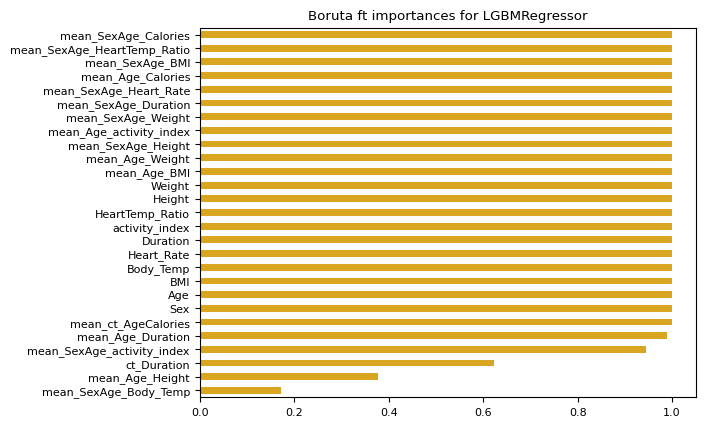

In [29]:
# calculate ft importances
importances = boruta(X, y, deepcopy(E), seed=10, plot=True, alpha=0.95, iterations=10)

__Features overview__

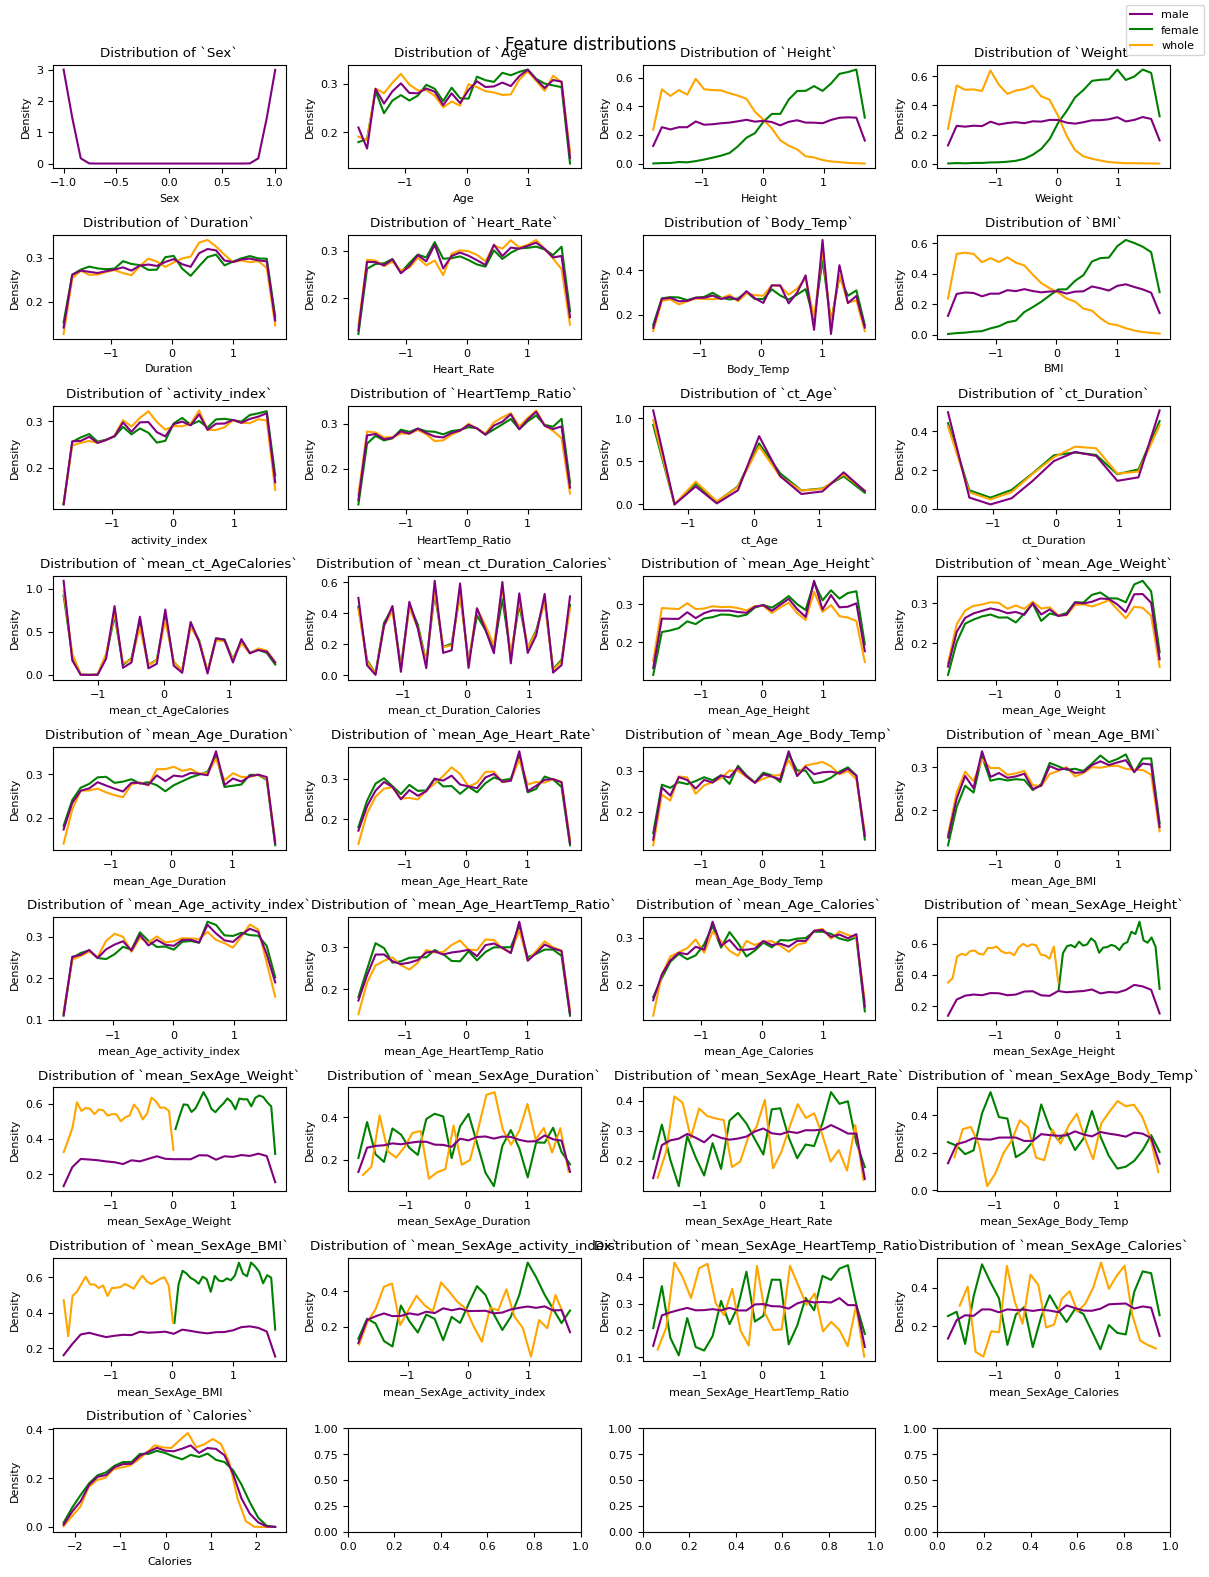

In [ ]:
data = X.copy()
# scaler = pre.PowerTransformer()
# data[TARGET] = scaler.fit_transform(y.to_numpy().reshape(-1, 1))
data[TARGET] = y

COLUMNS = 4
ROWS = np.ceil(len(data.columns) / COLUMNS).astype(int)
SIZE = (COLUMNS * 3, ROWS * 1.75)
plt.rcParams.update({'font.size': 8})

fig, ax = plt.subplots(ROWS, COLUMNS, figsize=SIZE)
fig.suptitle('Feature distributions', fontsize=12)
fig.set_layout_engine('tight')

MALE = data.Sex > 0.5
for n, feature in enumerate(data.columns):
    row, col = n // COLUMNS, n % COLUMNS
    if feature == 'Sex':
        feature_overview(ax[row][col], data[feature], FigureType.DENSITY, bins=25, color='purple')
    elif feature.startswith('ct_'):
        bins = data[feature].unique().size
        feature_overview(ax[row][col], data.loc[MALE, feature], FigureType.DENSITY, bins=bins, color='green')
        feature_overview(ax[row][col], data.loc[~MALE, feature], FigureType.DENSITY, bins=bins, color='orange')
        feature_overview(ax[row][col], data[feature], FigureType.DENSITY, bins=bins, color='purple')
    else:
        feature_overview(ax[row][col], data.loc[MALE, feature], FigureType.DENSITY, bins=25, color='green')
        feature_overview(ax[row][col], data.loc[~MALE, feature], FigureType.DENSITY, bins=25, color='orange')
        feature_overview(ax[row][col], data[feature], FigureType.DENSITY, bins=25, color='purple')

fig.legend(['male', 'female', 'whole'])
plt.show()

__Correlations__

In [24]:
# THRESHOLD = 0.0

# data = X.copy()
# labels = data.columns
# data[TARGET] = y

# CORRELATIONS = ('pearson', 'spearman', 'kendall')
# # CORRELATIONS = ('pearson', )
# # drawing
# fig, axes = plt.subplots(len(CORRELATIONS), 1, figsize=(12, 4.5), sharex=True)
# fig.set_layout_engine('compressed')
# fig.suptitle('Correlations')
# for n, method in enumerate(CORRELATIONS):
#     ax = axes[n] if len(CORRELATIONS) > 1 else axes
#     ax.set_title(method.capitalize())
#     target_corr = data.corr(method)[[TARGET]].drop(TARGET).sort_values(TARGET, ascending=False)
#     values = target_corr.values.squeeze()
#     filtered = (abs(values) > THRESHOLD)
#     ax.imshow(values[filtered].reshape(1, -1), cmap='Blues')
#     ax.set_xticks(range(len(labels[filtered])), labels=labels[filtered], rotation=90)
#     ax.set_yticks([0], labels=[TARGET])
# plt.show()

__Final fit__

In [111]:
E = LGBMRegressor(  # see more https://lightgbm.readthedocs.io/en/latest/Parameters.html
    # objective='gamma',
    # objective='quantile',
    # objective='poisson',
    n_estimators=2500,
    learning_rate=0.25,
    max_depth=3,
    n_jobs=-1,
    random_state=23,
    verbose=-1,
    # device_type='cuda'
)
_ = checkup(E, X, y, folds=3, scaler=y_pipe, clip=(1e-8, np.inf))
# importances = boruta(X, y, deepcopy(E), seed=10, plot=True, alpha=0.95, iterations=10)
lgbm = model = E.fit(X, y)

Fold: 0; TRAIN RMSLE=0.05600; | VALID RMSLE=0.06059
Fold: 1; TRAIN RMSLE=0.05601; | VALID RMSLE=0.05974
Fold: 2; TRAIN RMSLE=0.05608; | VALID RMSLE=0.06012
MEAN: TRAIN RMSLE=0.05603; | VALID RMSLE=0.06015


In [108]:
E = CatBoostRegressor(  # see more https://catboost.ai/docs/en/concepts/loss-functions-regression
    n_estimators=2500,
    learning_rate=0.15,
    max_depth=4,
    random_state=23,
    silent=True,
    allow_writing_files=False,
    task_type='GPU'
)
_ = checkup(E, X, y, folds=3, scaler=y_pipe, clip=(1e-8, np.inf))
# importances = boruta(X, y, E.copy(), seed=10, plot=True, alpha=0.95)
catboost = model = E.fit(X, y)

Fold: 0; TRAIN RMSLE=0.05633; | VALID RMSLE=0.06021
Fold: 1; TRAIN RMSLE=0.05625; | VALID RMSLE=0.05942
Fold: 2; TRAIN RMSLE=0.05633; | VALID RMSLE=0.05962
MEAN: TRAIN RMSLE=0.05630; | VALID RMSLE=0.05975


__Submission__

In [112]:
# LGBM
T = pipe.transform(test.drop(columns=TARGET))
# values = lgbm.predict(T)
values = y_pipe.inverse_transform(lgbm.predict(T).reshape(-1, 1))[:, 0]

if (test[TARGET] != values).any():
    filecode = uuid.uuid4().hex
    test[TARGET] = values
    test.reset_index()[['id', TARGET]].to_csv(f'{filecode}.csv', index=False)
    print(filecode)

35b27a2a9a7d4588a265504e6723909a


In [109]:
# CatBoost
T = pipe.transform(test.drop(columns=TARGET))
# values = catboost.predict(T)
values = y_pipe.inverse_transform(catboost.predict(T).reshape(-1, 1))[:, 0]

if (test[TARGET] != values).any():
    filecode = uuid.uuid4().hex
    test[TARGET] = values
    test.reset_index()[['id', TARGET]].to_csv(f'{filecode}.csv', index=False)
    print(filecode)

b844d5261d1447c89bf494df87f99c2c


In [ ]:
#